# TDA-JC and TDA-PF models for multi-systems application

**Created by:** Khang Luong  
**Department of Chemistry, Brandeis University**
#### **Reference:** *[Insert Reference Here Later]*
--- 
## Overview
This tutorial covers the application of the Tamm-Dancoff approximation (TDA) with Jaynes-Cummings (JC) and Pauli-Fierz (PF) models to systems containing multiple molecules. We explore **collective coupling** and the resulting polaritonic states.

By the end of this tutorial, you will be able to:
1. **Part 1:** Understand the theoretical framework of collective QED-TDA.
2. **Part 2:** Use the `qed` package to model multi-molecular systems.
3. **Part 3:** Analyze the scaling of Rabi splitting with the number of molecules.
4. **Part 4:** Recommended Exercises

---
# Environment Setup
Please review Lesson 1 for specif detail about how to setup the environment.

### 📦 Import and & Configuration

In [196]:
import numpy as np
from pyscf import gto, scf, tdscf
import scipy
import qed
from qed.tdscf.ghf import FewLevel # Required for multi-system JC and PF
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# Color for printing
RED    = "\033[91m"
GREEN  = "\033[92m"
YELLOW = "\033[93m"
BLUE   = "\033[94m"
RESET  = "\033[0m"

# Unit Conversion:
HF_TO_EV = 27.2114
EV_TO_HF = 1 / HF_TO_EV

print("✅ All the imports are successful!")

✅ All the imports are successful!


---
# 🗂️ Part 1: Theoretical Framework

### 1.1 Collective Light-Matter Coupling
When $N$ identical molecules are placed inside an optical cavity, they interact collectively with the same vacuum field mode. The effective coupling strength scales as:
$$\Omega_{coll} = \Omega_{single} \sqrt{N}$$
where $\Omega_{single}$ is the coupling of a single molecule. This enhancement allows for reaching the **strong coupling regime** even with relatively weak individual transition dipoles.

### 1.2 The Few-Level Approximation
Solving the full QED-TDA problem for a large number of molecules ($N > 10$) becomes computationally prohibitive due to the size of the electronic-photonic Hessian. 

The **Few-Level** model simplifies this by:
1.  Solving for the excited states of each molecule individually.
2.  Constructing a reduced Hamiltonian using only a subset of these excitations (e.g., the first few singlet transitions).
3.  Coupling these local excitons to the cavity mode and to each other (via dipole-dipole interactions).

This tutorial demonstrates how to use the `FewLevel` solver to study these collective effects efficiently.

---
# Part 2: How to implement
## 2.1 Define Multiple Molecules
Instead of one, you will define a list of geometries. For simplicity, we can use two formaldehyde molecules at different positions (separated by 10 Ångströms along the Y-axis).

In [197]:
geom1 = 'H -0.945 0.0 1.128; C 0.0 0.0 0.526; H 0.945 0.0 1.128; O 0.0 0.0 -0.677'
geom2 = 'H -0.945 10.0 1.128; C 0.0 10.0 0.526; H 0.945 10.0 1.128; O 0.0 10.0 -0.677'

geoms = [geom1, geom2]
mfs = []
tds = []

# Run electronic ground state and TDDFT for each molecule
for g in geoms:
    mol = gto.M(atom=g, basis='6-311++G')
    mf = scf.RKS(mol)
    mf.xc = 'pbe0'
    mf.kernel()

    td = tdscf.TDA(mf)
    td.nroots = 10
    td.kernel()

    mfs.append(mf)
    tds.append(td)

converged SCF energy = -114.361869449636
Excitation energies (eV)
[ 3.88373633  6.8047454   7.78074553  7.91209213  8.56941276  9.16570272
  9.76183175  9.969099   10.30385346 10.50729248]
converged SCF energy = -114.361869449636
Excitation energies (eV)
[ 3.88373633  6.8047454   7.78074553  7.91209213  8.56941276  9.16570272
  9.76183175  9.969099   10.30385346 10.50729248]


## 2.2 Setup the Collective Cavity
Here, we follow the same procedures as previous lessons. Please note that the cavity is shared by all molecules so we don't need a separate key for each of them. 

In [198]:
# Extract the transition dipole of the bright S2 state
trans_dip = tds[0].transition_dipole()[1] 
unit_dip = trans_dip / np.linalg.norm(trans_dip)

cavity_freq = np.array([tds[0].e[1]]) # Target the bright state frequency
cavity_mode = (unit_dip * 0.01).reshape(3, 1) 

key = {
    'cavity_freq': cavity_freq,
    'cavity_mode': cavity_mode
}

# Initialize JC or PF model for the collective system
cav_jc = qed.JC(mfs, key)
cav_pf = qed.PF(mfs, key)

scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2


## 2.3 Run Few-Level QED-TDA
For many molecules, the **Few-Level** approximation is the most efficient way to see collective effects.

In [199]:
# 1. Initialize the Few-Level solver 
qed_few = FewLevel(tds, cav_jc, key)
qed_few.cavity_model = 'JC' # or 'PF'
qed_few.nstates = 5 # number of state to solve for
qed_few.target_states = 'polariton'
qed_few.solver_algorithm = 'direct'
qed_few.solver_conv_prop = 'norm'
qed_few.level_shift = 0.0
qed_few.tolerance = 1e-8
qed_few.max_cycle = 100


# 2. Solve for collective polaritons
energies, vectors, trans_dips, mag_dip = qed_few.kernel()

# 3. Analyze Photon vs Electron character
weight_p, weight_e = qed_few.get_weights(vectors)

print(f"{'State':<6} {'Energy (eV)':<12} {'Photon %':<10}")
for i in range(len(energies)):
    print(f"{i+1:<6} {energies[i]*HF_TO_EV:<12.4f} {weight_p[i]*100:<10.2f}")
    

has_offdiag inter-fragment coupling? False
resonance_state: 2
has_offdiag inter-fragment coupling? False
State  Energy (eV)  Photon %  
1      3.8837       0.00      
2      3.8837       0.00      
3      6.7314       50.68     
4      6.8047       0.00      
5      6.8759       49.14     


## 2.4 Advanced: Inter-fragment Coupling
If you want to include dipole-dipole interactions between the molecules (not just their interaction with the cavity), you can set ```has_offdiag```:

In [200]:
qed_few.has_offdiag = True
energies_inter, _, _, _ = qed_few.kernel()

print(f"{'State':<6} {'Energy (eV)':<12}")
for i in range(len(energies_inter)):
    print(f"{i+1:<6} {energies_inter[i]*HF_TO_EV:<12.4f}")

has_offdiag inter-fragment coupling? True
State  Energy (eV) 
1      3.8837      
2      3.8837      
3      6.7320      
4      6.8036      
5      6.8764      


# 📊 Part 3: Energies vs Coupling for Multi-Systems

Here, we want to apply to a system of 10 molecules

Starting collective coupling scan for 10 molecules...
Progress: [1/20] λ = 0.0000 a.u.scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
has_offdiag inter-fragment coupling? False
resonance_state: 2
has_offdiag inter-fragment coupling? False
has_offdiag inter-fragment coupling? False
resonance_state: 2
has_offdiag inter-fragment coupling? False
Progress: [2/20] λ = 0.0026 a.u.scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2
scf_type: RKS
occupation: 2


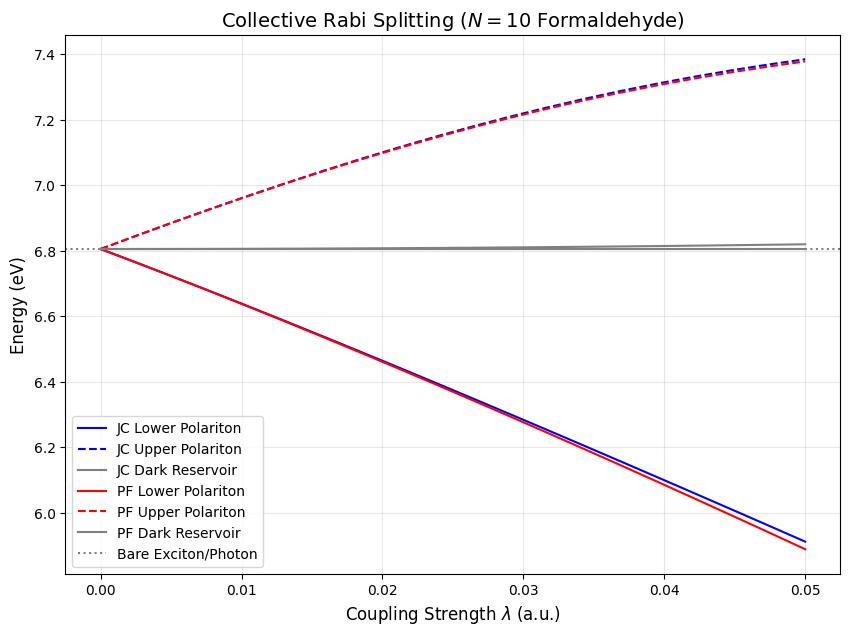

Conclusion: In the collective model, the splitting magnitude increases with the number of molecules.
The splitting is proportional to $$\sqrt{N} \cdot \lambda$$, a hallmark of superradiance.


In [201]:
n_mols = 10
lambdas = np.linspace(0.0, 0.05, 20) # Coupling range
target_freq = tds[0].e[1] # Tune to the second electronic excitation (S2-bright state)

# Replicate the single-molecule results for the collective model
rep_tds = [tds[0]] * n_mols
rep_mfs = [mfs[0]] * n_mols

jc_energies = []
pf_energies = []

trans_dip = tds[0].transition_dipole()[1]
unit_dip = trans_dip / np.linalg.norm(trans_dip)

print(f"{BLUE}Starting collective coupling scan for {n_mols} molecules...{RESET}")

for i, lam in enumerate(lambdas):
    # Simple progress indicator
    print(f"\rProgress: [{i+1}/{len(lambdas)}] λ = {lam:.4f} a.u.", end="")
    
    current_key = key.copy()
    current_key['cavity_freq'] = np.array([target_freq])
    current_key['cavity_mode'] = (unit_dip * lam).reshape(3, 1)
    current_key['scale_coupling'] = 0 

    # 1. Setup cavity objects
    cav_jc = qed.JC(rep_mfs, current_key)
    cav_pf = qed.PF(rep_mfs, current_key)

    # 2. Solve JC model
    sol_jc = FewLevel(rep_tds, cav_jc, current_key)
    sol_jc.cavity_model = 'JC'
    sol_jc.nstates = 22 # Here we need to include enough states to reach the S2 manifold
    sol_jc.target_states = 'polariton'
    sol_jc.solver_algorithm = 'direct'
    sol_jc.solver_conv_prop = 'norm'
    sol_jc.level_shift = 0.0
    sol_jc.tolerance = 1e-8
    sol_jc.max_cycle = 100


    e_jc, v_jc, _, _ = sol_jc.kernel()
    jc_energies.append(np.sort(e_jc))

    if i == len(lambdas) - 1: 
        final_v_jc = v_jc

    # 3. Solve PF model
    sol_pf = FewLevel(rep_tds, cav_pf, current_key)
    sol_pf.cavity_model = 'PF'
    sol_pf.nstates = 22
    sol_pf.target_states = 'polariton'
    sol_pf.solver_algorithm = 'direct'
    sol_pf.solver_conv_prop = 'norm'
    sol_pf.level_shift = 0.0
    sol_pf.tolerance = 1e-8
    sol_pf.max_cycle = 100
    e_pf, _, _, _ = sol_pf.kernel()
    pf_energies.append(np.sort(e_pf))

print(f"\n{GREEN}Scan complete!{RESET}")

jc_energies = np.array(jc_energies) * HF_TO_EV
pf_energies = np.array(pf_energies) * HF_TO_EV

# --- Plotting ---
plt.figure(figsize=(10, 7))

# Plot JC states (S2 manifold starts at index 10)
plt.plot(lambdas, jc_energies[:, 10], 'b-', label='JC Lower Polariton')
plt.plot(lambdas, jc_energies[:, 20], 'b--', label='JC Upper Polariton')
plt.plot(lambdas, jc_energies[:, 11], 'gray', label='JC Dark Reservoir')

# Plot PF states
plt.plot(lambdas, pf_energies[:, 10], 'r-', label='PF Lower Polariton')
plt.plot(lambdas, pf_energies[:, 20], 'r--', label='PF Upper Polariton')
plt.plot(lambdas, pf_energies[:, 11], 'gray', label='PF Dark Reservoir')

plt.axhline(y=target_freq*HF_TO_EV, color='gray', linestyle=':', label='Bare Exciton/Photon')
plt.xlabel('Coupling Strength $\lambda$ (a.u.)', fontsize=12)
plt.ylabel('Energy (eV)', fontsize=12)
plt.title(f'Collective Rabi Splitting ($N={n_mols}$ Formaldehyde)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f"{YELLOW}Conclusion:{RESET} In the collective model, the splitting magnitude increases with the number of molecules.")
print(f"The splitting is proportional to $$\\sqrt{{N}} \\cdot \\lambda$$, a hallmark of superradiance.")

### 3.1 Proving Superradiance: The Delocalized Wavefunction
The plot above shows that the Rabi splitting magnitude increases with $N$, but how do we know the molecules are actually acting collectively? 

If this is true superradiance, the Lower Polariton shouldn't just belong to one molecule. The photon's influence must be perfectly shared across the entire ensemble. We can prove this mathematically by extracting the photon and electron weights from the wavefunction of the Lower Polariton at our maximum coupling strength ($\lambda = 0.05$).

In [203]:
# Extract the eigenvectors for the final lambda step (where sol_jc is currently sitting)
weight_p, weight_e = sol_jc.get_weights(final_v_jc)

# Target the Lower Polariton of the S2 manifold (Index 10)
lp_photon_weight = weight_p[10] * 100
lp_electron_weights = weight_e[:, 10] * 100

print(f"{BLUE}--- Wavefunction Composition of the Lower Polariton ---{RESET}")
print(f"Total Photon Contribution:   {lp_photon_weight:.2f}%")
print(f"Total Electron Contribution: {np.sum(lp_electron_weights):.2f}%\n")

print("Electronic Contribution per molecule:")
for i, w in enumerate(lp_electron_weights):
    # Highlight that every single molecule has an identical share of the excitation
    print(f"  Molecule {i+1:<2}: {w:.2f}%")

--- Wavefunction Composition of the Lower Polariton ---
Total Photon Contribution:   52.84%
Total Electron Contribution: 47.16%

Electronic Contribution per molecule:
  Molecule 1 : 4.72%
  Molecule 2 : 4.72%
  Molecule 3 : 4.72%
  Molecule 4 : 4.72%
  Molecule 5 : 4.72%
  Molecule 6 : 4.72%
  Molecule 7 : 4.72%
  Molecule 8 : 4.72%
  Molecule 9 : 4.72%
  Molecule 10: 4.72%


---
# 🏋️ Part 4: Recommended Exercises

To truly master collective light-matter coupling, try modifying the code above to answer the following physical questions:

#### **Exercise 1: Proving the $\sqrt{N} Scaling Law$**
The hallmark of supperadiance is that the Rabi splitting ($\Omega_{UP}-\Omega_{LP}$) scales with the square root of the number of molecules ($\sqrt{N}$).
*   **Task:** Write a new loop that fixes the coupling strength at $\lambda=0.02$ a.u. Instead of scanning $\lambda$, scan the number of molecules: `N_list = [1, 2, 4, 8, 12, 16]`
*   **Analysis:** Extract the Upper and Lower PF polariton energies for each $N$, calculate the splitting, and plot it against $\sqrt{N}$ on the x-axis. What is the shape of the resulting curve?

#### **Exercise 2: The Breakdown of JC**
In this tutorial, we scanned up to $\lambda = 0.05$ a.u., where the TDA-JC and TDA-PF models give relatively similar results.
*   **Task:** Push the system into the deep ultra-strong coupling regime by changing the scan to `lambdas = np.linspace(0.0, 0.20, 20)`.
*   **Analysis:** Look closely at the upper and lower polariton branches. Does the JC model maintain a symmetric split? What happens to the PF model? Can you explain the physical origin of this difference (Hint: consider the role of higher-energy states and the Dipole Self-Energy)

#### **Exercise 3: Introducing Structural Disorder (Inhomogeneous Broadening)**
In our ideal simulation, all 10 molecules are perfectly identical. In a real cavity—especially one being probed by ultrafast techniques—thermal fluctuations and vibrations mean molecules are constantly changing their geometry.
*   **Task:** Manually introduce structural disorder. Modify the `geoms` list so that one or two of the formaldehyde molecules have their C=O bond slightly stretched (e.g., by 0.05 Å). Re-run the collective coupling calculation.
*   **Analysis:** What happens to the $N-1$ "Dark Reservoir" states that were previously perfectly flat and degenerate? Use the `get_weights()` function to look at the electronic distribution of the Lower Polariton. Is the excitation still perfectly delocalized (10% per molecule), or does the structural defect cause the state to localize?